<a href="https://colab.research.google.com/github/imyoumin/2026-2-DL/blob/main/chapter05_fundamentals_of_ml%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 13.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.32.0 which is incompatible.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Fundamentals of machine learning

### Generalization: The goal of machine learning

#### Underfitting and overfitting

##### Noisy training data

##### Ambiguous features

##### Rare features and spurious correlations

In [4]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8706 - loss: 0.4294 - val_accuracy: 0.9212 - val_loss: 0.2649
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9336 - loss: 0.2265 - val_accuracy: 0.9443 - val_loss: 0.1970
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9537 - loss: 0.1569 - val_accuracy: 0.9500 - val_loss: 0.1686
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9677 - loss: 0.1103 - val_accuracy: 0.9602 - val_loss: 0.1401
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9769 - loss: 0.0787 - val_accuracy: 0.9575 - val_loss: 0.1428
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9836 - loss: 0.0572 - val_accuracy: 0.9587 - val_loss: 0.1390
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9896 - loss: 0.0383 - val_accuracy: 0.9582 - val_loss: 0.1450
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9931 - loss: 0.0272 - val_accuracy: 0.

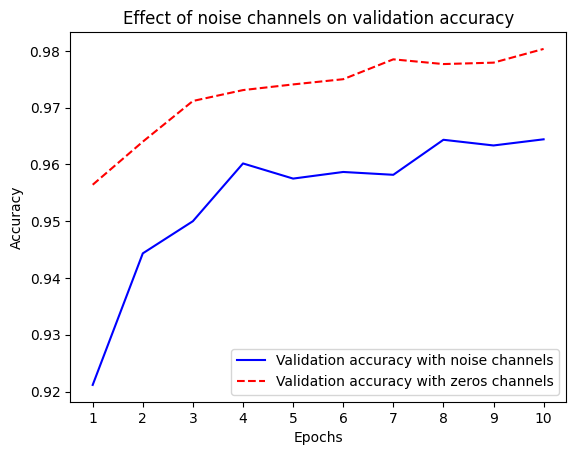

In [6]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)
plt.plot(
    epochs,
    val_acc_zeros,
    "r--",
    label="Validation accuracy with zeros channels",
)
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### The nature of generalization in deep learning

In [7]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1021 - loss: 2.3156 - val_accuracy: 0.1060 - val_loss: 2.3059
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1157 - loss: 2.2993 - val_accuracy: 0.1050 - val_loss: 2.3091
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1242 - loss: 2.2916 - val_accuracy: 0.1018 - val_loss: 2.3162
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1387 - loss: 2.2804 - val_accuracy: 0.1027 - val_loss: 2.3249
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1510 - loss: 2.2651 - val_accuracy: 0.1007 - val_loss: 2.3391
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1633 - loss: 2.2449 - val_accuracy: 0.1065 - val_loss: 2.3466
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1779 - loss: 2.2214 - val_accuracy: 0.1002 - val_loss: 2.3698
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1970 - loss: 2.1949 - val_accu

##### The manifold hypothesis

##### Interpolation as a source of generalization

##### Why deep learning works

##### Training data is paramount

### Evaluating machine-learning models

#### Training, validation, and test sets

##### Simple hold-out validation

##### K-fold validation

##### Iterated K-fold validation with shuffling

#### Beating a common-sense baseline

#### Things to keep in mind about model evaluation

### Improving model fit

#### Tuning key gradient descent parameters

In [8]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1126 - loss: 14.2700 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - val_accuracy: 0.1081 - val_loss: 14.3760
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1035 - loss: 14.4499 - v

In [9]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9070 - loss: 0.4239 - val_accuracy: 0.9607 - val_loss: 0.1403
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9646 - loss: 0.1274 - val_accuracy: 0.9502 - val_loss: 0.2052
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9742 - loss: 0.0963 - val_accuracy: 0.9651 - val_loss: 0.1666
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9781 - loss: 0.0854 - val_accuracy: 0.9688 - val_loss: 0.1563
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9840 - loss: 0.0674 - val_accuracy: 0.9653 - val_loss: 0.2032
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9857 - loss: 0.0593 - val_accuracy: 0.9726 - val_loss: 0.1623
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9870 - loss: 0.0564 - val_accuracy: 0.9739 - val_loss: 0.1670
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9891 - loss: 0.0500 - val_accuracy: 0.

#### Using better architecture priors

#### Increasing model capacity

In [10]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_small_model = model.fit(
    train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8349 - loss: 0.6717 - val_accuracy: 0.9034 - val_loss: 0.3594
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9024 - loss: 0.3524 - val_accuracy: 0.9156 - val_loss: 0.3077
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9110 - loss: 0.3177 - val_accuracy: 0.9190 - val_loss: 0.2915
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9160 - loss: 0.3016 - val_accuracy: 0.9197 - val_loss: 0.2855
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9189 - loss: 0.2917 - val_accuracy: 0.9223 - val_loss: 0.2777
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9204 - loss: 0.2853 - val_accuracy: 0.9250 - val_loss: 0.2744
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9220 - loss: 0.2803 - val_accuracy: 0.9262 - val_loss: 0.2722
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9231 - loss: 0.2765 - val_accuracy: 0.

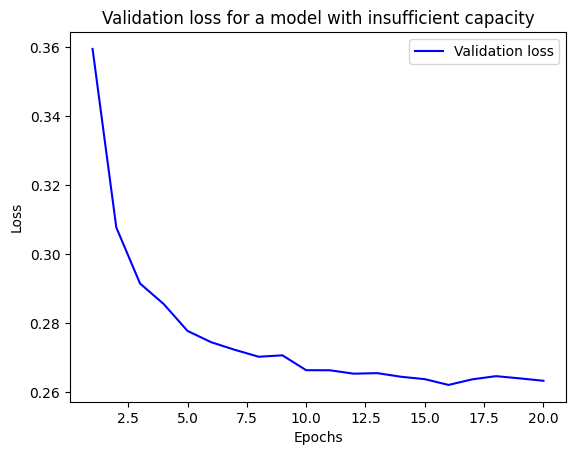

In [11]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [12]:
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9005 - loss: 0.3520 - val_accuracy: 0.9438 - val_loss: 0.1914
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9527 - loss: 0.1565 - val_accuracy: 0.9646 - val_loss: 0.1272
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9680 - loss: 0.1069 - val_accuracy: 0.9687 - val_loss: 0.1082
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9757 - loss: 0.0797 - val_accuracy: 0.9701 - val_loss: 0.1049
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9810 - loss: 0.0622 - val_accuracy: 0.9710 - val_loss: 0.0941
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9844 - loss: 0.0496 - val_accuracy: 0.9732 - val_loss: 0.0882
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9878 - loss: 0.0393 - val_accuracy: 0.9751 - val_loss: 0.0904
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9895 - loss: 0.0325 - val_accuracy: 0.

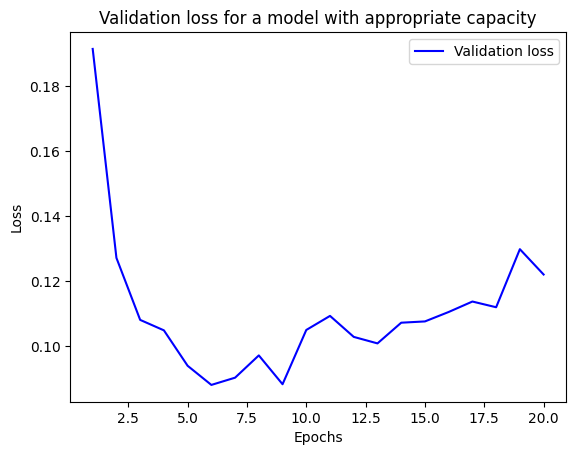

In [13]:
val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with appropriate capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
model = keras.Sequential(
    [
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_very_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9274 - loss: 0.2569 - val_accuracy: 0.9574 - val_loss: 0.1557
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9684 - loss: 0.1176 - val_accuracy: 0.9719 - val_loss: 0.1187
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9782 - loss: 0.0845 - val_accuracy: 0.9688 - val_loss: 0.1397
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9829 - loss: 0.0698 - val_accuracy: 0.9720 - val_loss: 0.1271
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9872 - loss: 0.0565 - val_accuracy: 0.9748 - val_loss: 0.1475
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9899 - loss: 0.0459 - val_accuracy: 0.9803 - val_loss: 0.1214
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9911 - loss: 0.0400 - val_accuracy: 0.9766 - val_loss: 0.1299
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9940 - loss: 0.0295 - 

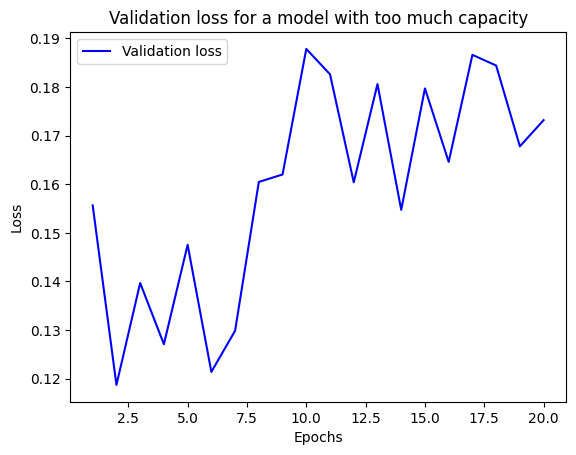

In [15]:
val_loss = history_very_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with too much capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Improving generalization

#### Dataset curation

#### Feature engineering

#### Using early stopping

#### Regularizing your model

##### Reducing the network's size

In [16]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_original = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.7836 - loss: 0.5075 - val_accuracy: 0.8669 - val_loss: 0.3789
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8977 - loss: 0.3057 - val_accuracy: 0.8868 - val_loss: 0.3001
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9215 - loss: 0.2309 - val_accuracy: 0.8902 - val_loss: 0.2831
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9387 - loss: 0.1853 - val_accuracy: 0.8737 - val_loss: 0.3055
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9501 - loss: 0.1543 - val_accuracy: 0.8875 - val_loss: 0.2830
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9585 - loss: 0.1314 - val_accuracy: 0.8877 - val_loss: 0.2877
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9652 - loss: 0.1149 - val_accuracy: 0.8847 - val_loss: 0.3001
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accurac

In [17]:
model = keras.Sequential(
    [
        layers.Dense(4, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_smaller_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7685 - loss: 0.5826 - val_accuracy: 0.8520 - val_loss: 0.4883
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8815 - loss: 0.4214 - val_accuracy: 0.8685 - val_loss: 0.3946
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9018 - loss: 0.3316 - val_accuracy: 0.8806 - val_loss: 0.3386
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9155 - loss: 0.2742 - val_accuracy: 0.8867 - val_loss: 0.3061
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9283 - loss: 0.2336 - val_accuracy: 0.8861 - val_loss: 0.2905
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9360 - loss: 0.2041 - val_accuracy: 0.8921 - val_loss: 0.2786
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9442 - loss: 0.1802 - val_accuracy: 0.8905 - val_loss: 0.2748
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9524 - loss: 0.1602 - val_accuracy: 0.8919 - v

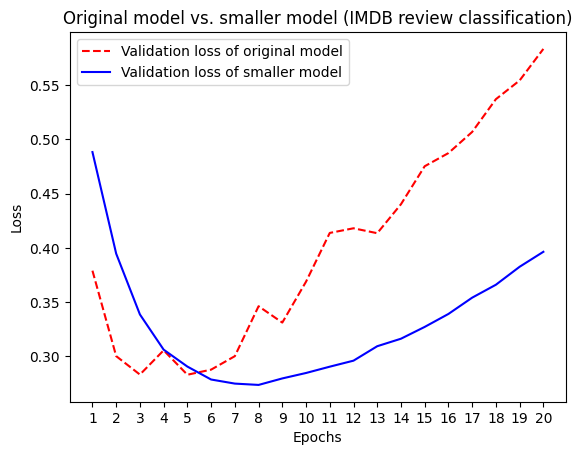

In [18]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.title("Original model vs. smaller model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [19]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_larger_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.7247 - loss: 0.5713 - val_accuracy: 0.8692 - val_loss: 0.3522
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8723 - loss: 0.3193 - val_accuracy: 0.7954 - val_loss: 0.4809
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9055 - loss: 0.2444 - val_accuracy: 0.7971 - val_loss: 0.5051
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9281 - loss: 0.1864 - val_accuracy: 0.8521 - val_loss: 0.3593
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9443 - loss: 0.1488 - val_accuracy: 0.8886 - val_loss: 0.2810
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9565 - loss: 0.1282 - val_accuracy: 0.8863 - val_loss: 0.2759
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9813 - loss: 0.0636 - val_accuracy: 0.8299 - val_loss: 0.4918
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9775 - loss: 0.0706 - val_accuracy: 0.8865 - v

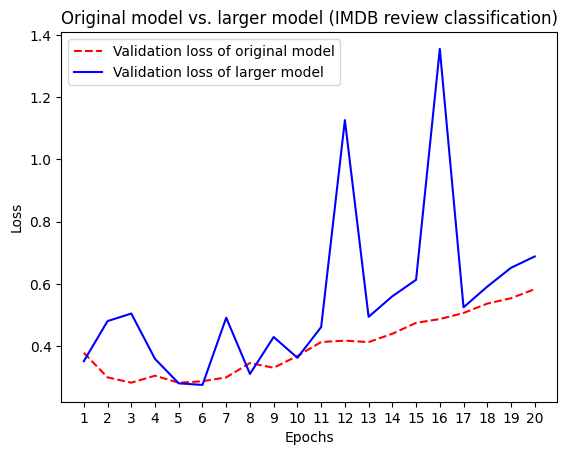

In [20]:
original_val_loss = history_original.history["val_loss"]
larger_model_val_loss = history_larger_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    larger_model_val_loss,
    "b-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

##### Adding weight regularization

In [21]:
from keras.regularizers import l2

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.7676 - loss: 0.6381 - val_accuracy: 0.8648 - val_loss: 0.5018
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8841 - loss: 0.4370 - val_accuracy: 0.8800 - val_loss: 0.4077
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9068 - loss: 0.3565 - val_accuracy: 0.8851 - val_loss: 0.3715
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9195 - loss: 0.3132 - val_accuracy: 0.8753 - val_loss: 0.3826
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9269 - loss: 0.2876 - val_accuracy: 0.8808 - val_loss: 0.3665
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9339 - loss: 0.2695 - val_accuracy: 0.8836 - val_loss: 0.3636
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9384 - loss: 0.2570 - val_accuracy: 0.8842 - val_loss: 0.3653
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9442 - loss: 0.2461 - val_accuracy: 0.8832 - v

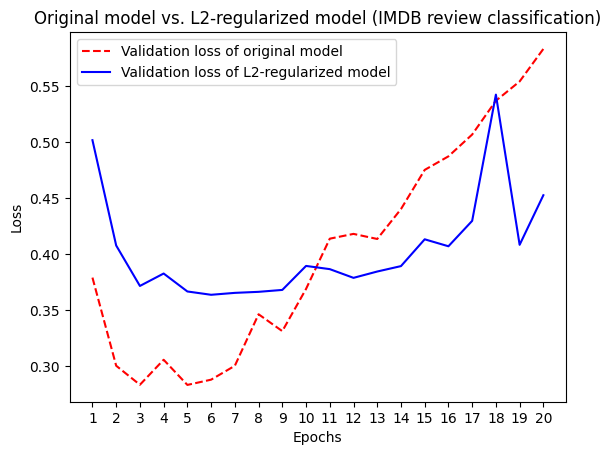

In [22]:
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of L2-regularized model",
)
plt.title(
    "Original model vs. L2-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [23]:
from keras import regularizers

regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

##### Adding dropout

In [24]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.6404 - loss: 0.6284 - val_accuracy: 0.8288 - val_loss: 0.4819
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7857 - loss: 0.4909 - val_accuracy: 0.8608 - val_loss: 0.3902
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8375 - loss: 0.4070 - val_accuracy: 0.8723 - val_loss: 0.3331
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8696 - loss: 0.3401 - val_accuracy: 0.8882 - val_loss: 0.2922
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8927 - loss: 0.3029 - val_accuracy: 0.8814 - val_loss: 0.3018
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9076 - loss: 0.2630 - val_accuracy: 0.8809 - val_loss: 0.2888
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9176 - loss: 0.2302 - val_accuracy: 0.8869 - val_loss: 0.2973
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9288 - loss: 0.2134 - val_accuracy: 0.8888 - v

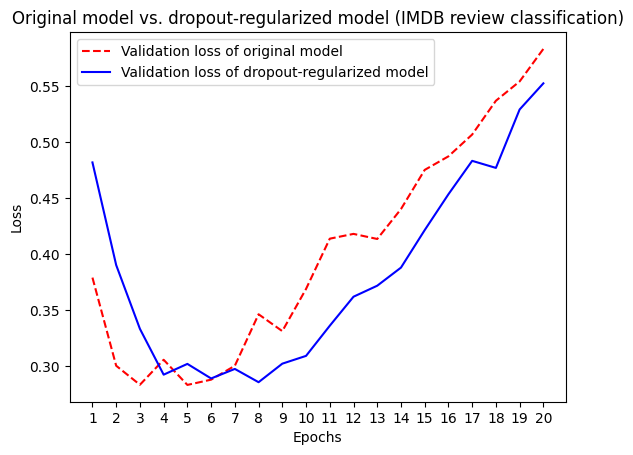

In [25]:
original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)
plt.title(
    "Original model vs. dropout-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

# 수업 실습 (09/30)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9166 - loss: 0.2959 - val_accuracy: 0.9571 - val_loss: 0.1508
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9649 - loss: 0.1238 - val_accuracy: 0.9695 - val_loss: 0.1056
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9760 - loss: 0.0826 - val_accuracy: 0.9718 - val_loss: 0.0955
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9828 - loss: 0.0583 - val_accuracy: 0.9728 - val_loss: 0.0879
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9881 - loss: 0.0417 - val_accuracy: 0.9747 - val_loss: 0.0877
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9910 - loss: 0.0320 - val_accuracy: 0.9759 - val_loss: 0.0802
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9938 - loss: 0.0235 - val_accuracy: 0.9762 - val_loss: 0.0763
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9959 - loss: 0.0175 - val_accuracy: 0.

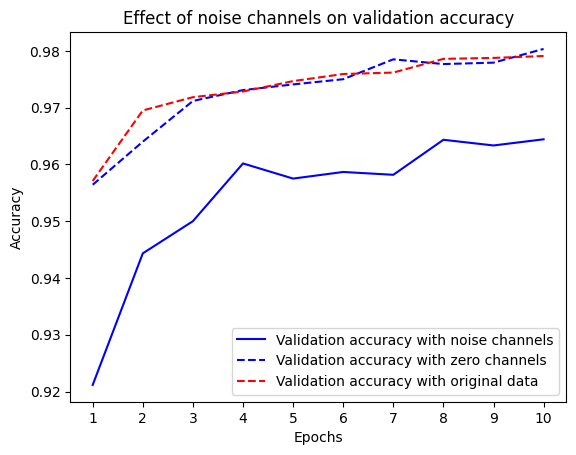

In [28]:
# Q1. Compare original MNIST with noise channels and zero channels

from keras.datasets import mnist
import matplotlib.pyplot as plt

# MNIST 다시 불러오기
(train_images_mnist, train_labels_mnist), _ = mnist.load_data()

train_images_mnist = train_images_mnist.reshape((60000, 28 * 28))
train_images_mnist = train_images_mnist.astype("float32") / 255


# Original MNIST data로 동일한 모델 학습
model_original = get_model()

history_original_mnist = model_original.fit(
    train_images_mnist,
    train_labels_mnist,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)


# Validation accuracy
val_acc_original = history_original_mnist.history["val_accuracy"]
val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]

epochs = range(1, 11)


# Plot
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)

plt.plot(
    epochs,
    val_acc_zeros,
    "b--",
    label="Validation accuracy with zero channels",
)

plt.plot(
    epochs,
    val_acc_original,
    "r--",
    label="Validation accuracy with original data",
)

plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.show()

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1040 - loss: 2.3148 - val_accuracy: 0.1035 - val_loss: 2.3052
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1208 - loss: 2.2986 - val_accuracy: 0.1060 - val_loss: 2.3111
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1306 - loss: 2.2898 - val_accuracy: 0.1067 - val_loss: 2.3204
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1410 - loss: 2.2778 - val_accuracy: 0.1036 - val_loss: 2.3279
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1532 - loss: 2.2609 - val_accuracy: 0.1004 - val_loss: 2.3377
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1673 - loss: 2.2425 - val_accuracy: 0.0987 - val_loss: 2.3479
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1822 - loss: 2.2194 - val_accuracy: 0.0985 - val_loss: 2.3655
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1980 - loss: 2.1925 - val_accu

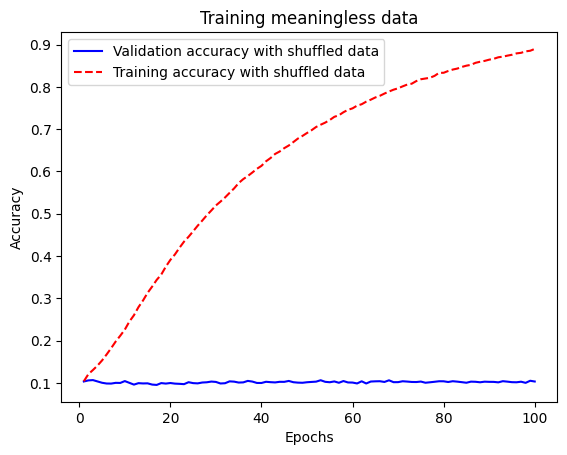

In [29]:
# Q2. Train MNIST with randomly shuffled labels
# and visualize training / validation accuracy

from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers


# MNIST 다시 불러오기
(train_images_mnist, train_labels_mnist), _ = mnist.load_data()

train_images_mnist = train_images_mnist.reshape((60000, 28 * 28))
train_images_mnist = train_images_mnist.astype("float32") / 255


# Label 무작위 섞기
random_train_labels = train_labels_mnist.copy()
np.random.shuffle(random_train_labels)


# Same MNIST model
model_shuffled = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

model_shuffled.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


# Train
history_shuffled = model_shuffled.fit(
    train_images_mnist,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)


# Accuracy
train_acc = history_shuffled.history["accuracy"]
val_acc = history_shuffled.history["val_accuracy"]

epochs = range(1, len(train_acc) + 1)


# Plot
plt.plot(
    epochs,
    val_acc,
    "b-",
    label="Validation accuracy with shuffled data",
)

plt.plot(
    epochs,
    train_acc,
    "r--",
    label="Training accuracy with shuffled data",
)

plt.title("Training meaningless data")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

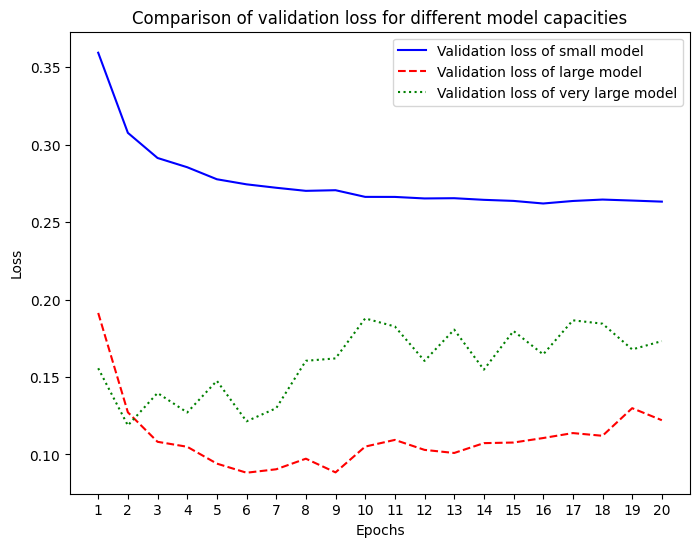

In [30]:
# Compare validation loss of different model capacities

import matplotlib.pyplot as plt

small_model_val_loss = history_small_model.history["val_loss"]
large_model_val_loss = history_large_model.history["val_loss"]
very_large_model_val_loss = history_very_large_model.history["val_loss"]

epochs = range(1, 21)

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    small_model_val_loss,
    "b-",
    label="Validation loss of small model"
)

plt.plot(
    epochs,
    large_model_val_loss,
    "r--",
    label="Validation loss of large model"
)

plt.plot(
    epochs,
    very_large_model_val_loss,
    "g:",
    label="Validation loss of very large model"
)

plt.title("Comparison of validation loss for different model capacities")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.xticks(epochs)
plt.legend()

plt.show()

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9158 - loss: 0.2920 - val_accuracy: 0.9591 - val_loss: 0.1465
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9642 - loss: 0.1225 - val_accuracy: 0.9672 - val_loss: 0.1093
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9766 - loss: 0.0806 - val_accuracy: 0.9728 - val_loss: 0.0936
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9830 - loss: 0.0585 - val_accuracy: 0.9740 - val_loss: 0.0847
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9868 - loss: 0.0441 - val_accuracy: 0.9764 - val_loss: 0.0773
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9901 - loss: 0.0340 - val_accuracy: 0.9771 - val_loss: 0.0776
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9927 - loss: 0.0249 - val_accuracy: 0.9786 - val_loss: 0.0735
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9953 - loss: 0.0189 - val_accuracy: 0.

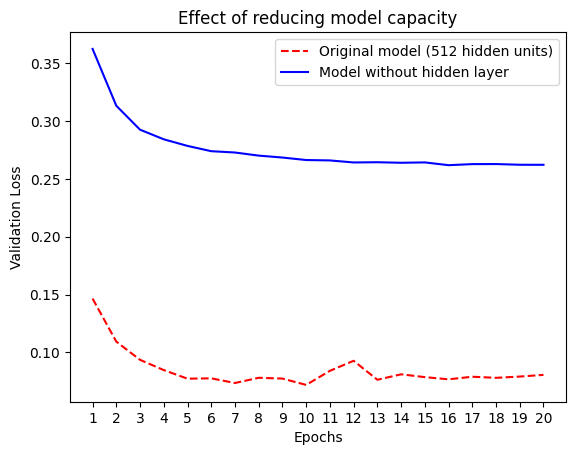

In [31]:
import keras
from keras import layers
from keras.datasets import mnist
import matplotlib.pyplot as plt

# MNIST
(train_images, train_labels), _ = mnist.load_data()

train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255


# --------------------------------------------------
# 1. Original model: Dense(512) + Dense(10)
# --------------------------------------------------
original_model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

original_model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_original = original_model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)


# --------------------------------------------------
# 2. Modified model: Dense(512) 제거
# --------------------------------------------------
small_model = keras.Sequential(
    [
        # layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

small_model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_small = small_model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)


# --------------------------------------------------
# Validation loss 비교
# --------------------------------------------------
epochs = range(1, 21)

plt.plot(
    epochs,
    history_original.history["val_loss"],
    "r--",
    label="Original model (512 hidden units)"
)

plt.plot(
    epochs,
    history_small.history["val_loss"],
    "b-",
    label="Model without hidden layer"
)

plt.title("Effect of reducing model capacity")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9138 - loss: 0.3331 - val_accuracy: 0.9403 - val_loss: 0.2228
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9656 - loss: 0.1242 - val_accuracy: 0.9663 - val_loss: 0.1418
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9739 - loss: 0.1003 - val_accuracy: 0.9713 - val_loss: 0.1283
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9793 - loss: 0.0845 - val_accuracy: 0.9653 - val_loss: 0.1731
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9828 - loss: 0.0712 - val_accuracy: 0.9712 - val_loss: 0.1587
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9850 - loss: 0.0623 - val_accuracy: 0.9743 - val_loss: 0.1470
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9868 - loss: 0.0590 - val_accuracy: 0.9749 - val_loss: 0.1574
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9884 - loss: 0.0524 - val_accuracy: 0.

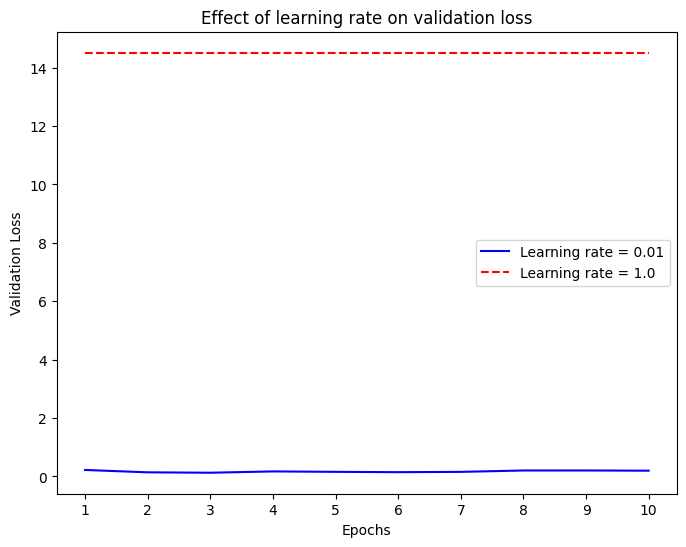

In [32]:
# Q1. Compare different learning rates

import keras
from keras import layers
from keras.datasets import mnist
import matplotlib.pyplot as plt

# MNIST 다시 불러오기
(train_images_mnist, train_labels_mnist), _ = mnist.load_data()

train_images_mnist = train_images_mnist.reshape((60000, 28 * 28))
train_images_mnist = train_images_mnist.astype("float32") / 255


def make_model(learning_rate):
    model = keras.Sequential([
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.RMSprop(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Learning rate = 0.01
model_lr_001 = make_model(1e-2)

history_lr_001 = model_lr_001.fit(
    train_images_mnist,
    train_labels_mnist,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)


# Learning rate = 1.0
model_lr_1 = make_model(1.0)

history_lr_1 = model_lr_1.fit(
    train_images_mnist,
    train_labels_mnist,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)


# Visualization
epochs = range(1, 11)

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    history_lr_001.history["val_loss"],
    "b-",
    label="Learning rate = 0.01"
)

plt.plot(
    epochs,
    history_lr_1.history["val_loss"],
    "r--",
    label="Learning rate = 1.0"
)

plt.title("Effect of learning rate on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

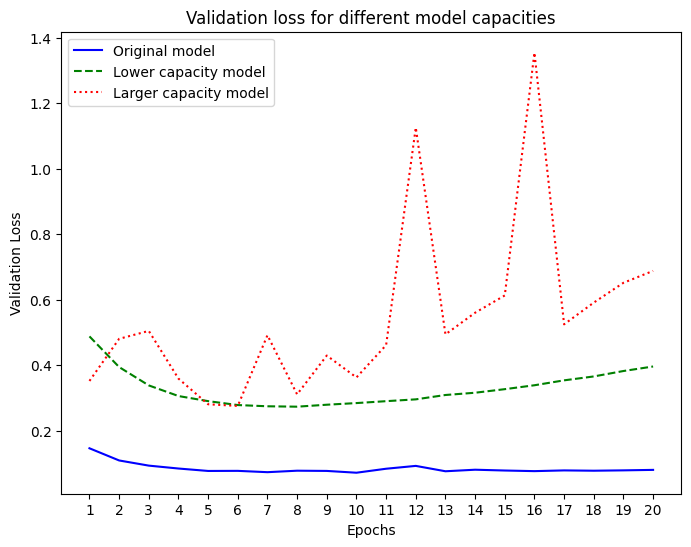

In [33]:
# Q2. Compare model capacities

import matplotlib.pyplot as plt

original_val_loss = history_original.history["val_loss"]
smaller_val_loss = history_smaller_model.history["val_loss"]
larger_val_loss = history_larger_model.history["val_loss"]

epochs = range(1, 21)

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    original_val_loss,
    "b-",
    label="Original model"
)

plt.plot(
    epochs,
    smaller_val_loss,
    "g--",
    label="Lower capacity model"
)

plt.plot(
    epochs,
    larger_val_loss,
    "r:",
    label="Larger capacity model"
)

plt.title("Validation loss for different model capacities")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

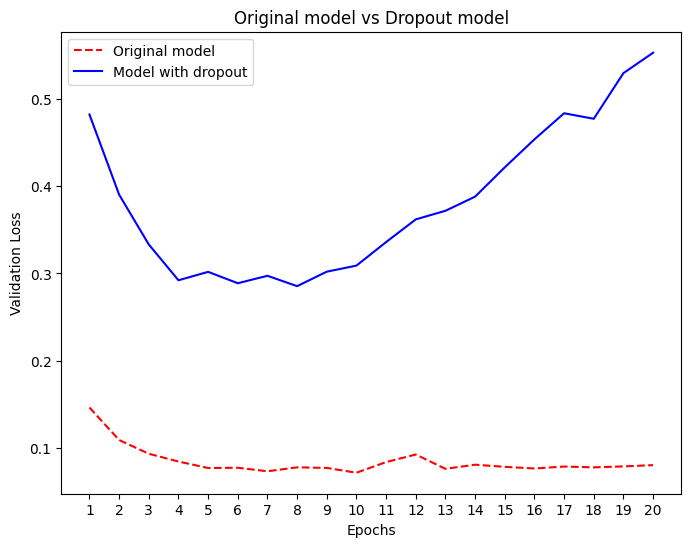

In [34]:
# Q3. Original model vs Dropout model

import matplotlib.pyplot as plt

original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]

epochs = range(1, 21)

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Original model"
)

plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Model with dropout"
)

plt.title("Original model vs Dropout model")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9150 - loss: 0.2979 - val_accuracy: 0.9568 - val_loss: 0.1543
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9646 - loss: 0.1231 - val_accuracy: 0.9677 - val_loss: 0.1111
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9769 - loss: 0.0789 - val_accuracy: 0.9737 - val_loss: 0.0897
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9834 - loss: 0.0565 - val_accuracy: 0.9751 - val_loss: 0.0809
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9886 - loss: 0.0412 - val_accuracy: 0.9784 - val_loss: 0.0736
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9916 - loss: 0.0310 - val_accuracy: 0.9768 - val_loss: 0.0783
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9943 - loss: 0.0226 - val_accuracy: 0.9783 - val_loss: 0.0755
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9962 - loss: 0.0162 - val_accuracy: 0.

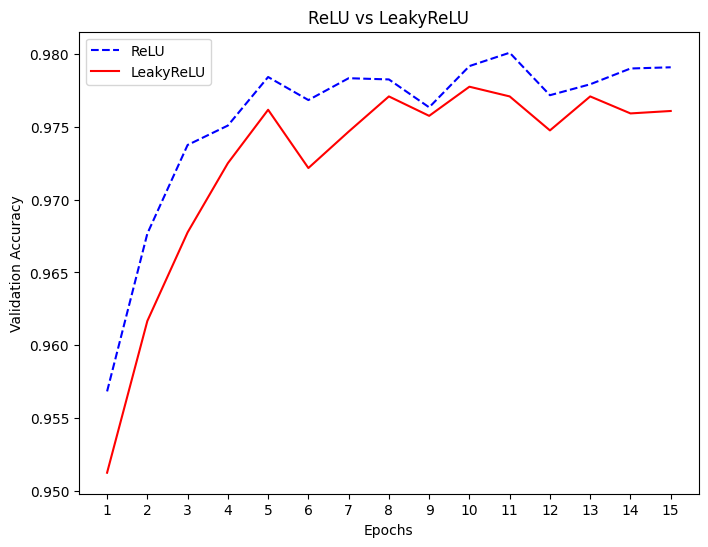

Best ReLU val accuracy: 0.9800833463668823
Best LeakyReLU val accuracy: 0.9777500033378601


In [36]:
# ReLU vs LeakyReLU fair comparison

import keras
from keras import layers
from keras.datasets import mnist
import matplotlib.pyplot as plt

# MNIST
(train_images, train_labels), _ = mnist.load_data()

train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255


# ReLU model
relu_model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

relu_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_relu = relu_model.fit(
    train_images,
    train_labels,
    epochs=15,
    batch_size=128,
    validation_split=0.2
)


# LeakyReLU model
leaky_model = keras.Sequential([
    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.1),
    layers.Dense(10, activation="softmax")
])

leaky_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_leaky = leaky_model.fit(
    train_images,
    train_labels,
    epochs=15,
    batch_size=128,
    validation_split=0.2
)


# Accuracy comparison
epochs = range(1, 16)

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    history_relu.history["val_accuracy"],
    "b--",
    label="ReLU"
)

plt.plot(
    epochs,
    history_leaky.history["val_accuracy"],
    "r-",
    label="LeakyReLU"
)

plt.title("ReLU vs LeakyReLU")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.xticks(epochs)
plt.legend()
plt.show()


print("Best ReLU val accuracy:",
      max(history_relu.history["val_accuracy"]))

print("Best LeakyReLU val accuracy:",
      max(history_leaky.history["val_accuracy"]))

In [ ]:
# ============================================================
# Hyperparameter tuning + Best model vs Original model
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras
from keras import layers
from keras.datasets import mnist


# ------------------------------------------------------------
# 1. MNIST
# ------------------------------------------------------------

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255


# ------------------------------------------------------------
# 2. Original model
# ------------------------------------------------------------

def make_original_model():

    model = keras.Sequential([
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# 3. Custom model generator
# ------------------------------------------------------------

def make_custom_model(
    units=512,
    activation="relu",
    batchnorm=False,
    dropout=0.0,
    learning_rate=0.001
):

    model = keras.Sequential()

    model.add(layers.Input(shape=(784,)))

    model.add(layers.Dense(units))

    # Batch Normalization
    if batchnorm:
        model.add(layers.BatchNormalization())

    # Activation
    if activation == "relu":
        model.add(layers.Activation("relu"))

    elif activation == "leaky_relu":
        model.add(
            layers.LeakyReLU(
                negative_slope=0.1
            )
        )

    # Dropout
    if dropout > 0:
        model.add(layers.Dropout(dropout))

    # Output
    model.add(
        layers.Dense(
            10,
            activation="softmax"
        )
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# 4. Test combinations
# ------------------------------------------------------------

configs = [

    # units, activation, batchnorm, dropout, learning_rate

    (256, "relu",       False, 0.0, 0.001),
    (256, "relu",       True,  0.0, 0.001),
    (256, "relu",       True,  0.1, 0.001),
    (256, "relu",       True,  0.2, 0.001),

    (512, "relu",       False, 0.0, 0.001),
    (512, "relu",       True,  0.0, 0.001),
    (512, "relu",       True,  0.1, 0.001),
    (512, "relu",       True,  0.2, 0.001),

    (512, "leaky_relu", False, 0.0, 0.001),
    (512, "leaky_relu", True,  0.0, 0.001),
    (512, "leaky_relu", True,  0.1, 0.001),
    (512, "leaky_relu", True,  0.2, 0.001),

    # learning rate 변경
    (512, "relu",       True,  0.1, 0.0005),
    (512, "relu",       True,  0.1, 0.0003),

    (512, "leaky_relu", True,  0.1, 0.0005),
    (512, "leaky_relu", True,  0.1, 0.0003),
]


results = []

best_val_accuracy = 0
best_config = None
best_model = None
best_history = None


# ------------------------------------------------------------
# 5. Training
# ------------------------------------------------------------

for i, config in enumerate(configs):

    units, activation, batchnorm, dropout, lr = config

    print("\n")
    print("=" * 70)
    print(f"Model {i+1}/{len(configs)}")
    print(
        f"units={units}, "
        f"activation={activation}, "
        f"batchnorm={batchnorm}, "
        f"dropout={dropout}, "
        f"lr={lr}"
    )
    print("=" * 70)

    keras.backend.clear_session()

    model = make_custom_model(
        units=units,
        activation=activation,
        batchnorm=batchnorm,
        dropout=dropout,
        learning_rate=lr
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        train_images,
        train_labels,
        epochs=15,
        batch_size=128,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    max_val_acc = max(
        history.history["val_accuracy"]
    )

    best_epoch = (
        np.argmax(history.history["val_accuracy"])
        + 1
    )

    print(
        f"Best Validation Accuracy: "
        f"{max_val_acc:.4f}"
    )

    print(
        f"Best Epoch: {best_epoch}"
    )

    results.append({
        "Model": i + 1,
        "Units": units,
        "Activation": activation,
        "BatchNorm": batchnorm,
        "Dropout": dropout,
        "Learning Rate": lr,
        "Best Epoch": best_epoch,
        "Best Val Accuracy": max_val_acc
    })

    # 현재 최고 모델 저장
    if max_val_acc > best_val_accuracy:

        best_val_accuracy = max_val_acc
        best_config = config
        best_model = model
        best_history = history


# ------------------------------------------------------------
# 6. Results table
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Best Val Accuracy",
    ascending=False
)

print("\n\n========== Hyperparameter Tuning Results ==========\n")

display(results_df)


# ------------------------------------------------------------
# 7. Best configuration
# ------------------------------------------------------------

print("\n========== BEST MODEL ==========")

print("Units:", best_config[0])
print("Activation:", best_config[1])
print("BatchNorm:", best_config[2])
print("Dropout:", best_config[3])
print("Learning Rate:", best_config[4])

print(
    "Best Validation Accuracy:",
    round(best_val_accuracy, 4)
)


# ------------------------------------------------------------
# 8. Train Original Model
# ------------------------------------------------------------

print("\n========== ORIGINAL MODEL ==========")

original_model = make_original_model()

early_stop_original = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

history_original = original_model.fit(
    train_images,
    train_labels,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop_original],
    verbose=0
)


# ------------------------------------------------------------
# 9. Test accuracy
# ------------------------------------------------------------

original_test_loss, original_test_acc = original_model.evaluate(
    test_images,
    test_labels,
    verbose=0
)

best_test_loss, best_test_acc = best_model.evaluate(
    test_images,
    test_labels,
    verbose=0
)


print("\n========== FINAL COMPARISON ==========")

print(
    f"Original Test Accuracy : "
    f"{original_test_acc:.4f}"
)

print(
    f"Best Custom Test Accuracy : "
    f"{best_test_acc:.4f}"
)

print(
    f"Improvement : "
    f"{(best_test_acc - original_test_acc) * 100:.2f}%p"
)


# ------------------------------------------------------------
# 10. Validation Accuracy comparison
# ------------------------------------------------------------

original_val_acc = history_original.history["val_accuracy"]
best_val_acc = best_history.history["val_accuracy"]

plt.figure(figsize=(8, 6))

plt.plot(
    range(1, len(original_val_acc) + 1),
    original_val_acc,
    "b--",
    label="Original model"
)

plt.plot(
    range(1, len(best_val_acc) + 1),
    best_val_acc,
    "r-",
    label="Best custom model"
)

plt.title("Original Model vs Best Custom Model")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


# ------------------------------------------------------------
# 11. Validation Loss comparison
# ------------------------------------------------------------

original_val_loss = history_original.history["val_loss"]
best_val_loss = best_history.history["val_loss"]

plt.figure(figsize=(8, 6))

plt.plot(
    range(1, len(original_val_loss) + 1),
    original_val_loss,
    "b--",
    label="Original model"
)

plt.plot(
    range(1, len(best_val_loss) + 1),
    best_val_loss,
    "r-",
    label="Best custom model"
)

plt.title("Validation Loss: Original vs Best Custom Model")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()